In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ryd_gate import RydbergSystem, simulate
from ryd_gate.lattice import make_square_lattice
from ryd_gate.protocols.digital_analog import DigitalAnalogProtocol, Segment
from ryd_gate.model.system import InteractionSpec


The whole Hamiltonian is:
$$
\begin{align*}
&H(t)/\hbar =
\sum_i \frac{\Omega_{R,i}(t)}{2}
\left(|r_i\rangle\langle 1_i|+\mathrm{h.c.}\right)
-\sum_i \Delta_{R,i}(t) n_i^r\\
&+
\sum_i \frac{\Omega_{\rm hf,i}(t)}{2}
\left(|1_i\rangle\langle0_i|+\mathrm{h.c.}\right)
-\sum_i \Delta_{\rm hf,i}(t) n_i^1
+
\sum_{i<j}V_{ij}n_i^r n_j^r ,
\end{align*}
$$

Considering $\Omega_R \equiv \Omega_{\text{eff}}=\frac{\Omega_{420}\Omega_{1013}}{2|\Delta|}$

- If we use（`Ω420/2π=237 MHz`, `Ω1013/2π=303 MHz`, `Δ/2π=7.8 GHz`）：$\Omega_R/2\pi \approx 4.60\ \text{MHz}$
- If we use（`Ω420≈Ω1013≈135 MHz`, `Δ≈2.4 GHz`）：$\Omega_R/2\pi \approx 3.80\ \text{MHz}$

`OMEGA_R = 2*np.pi*(3.1e6 ~ 6.0e6)` is thus a appropriate range

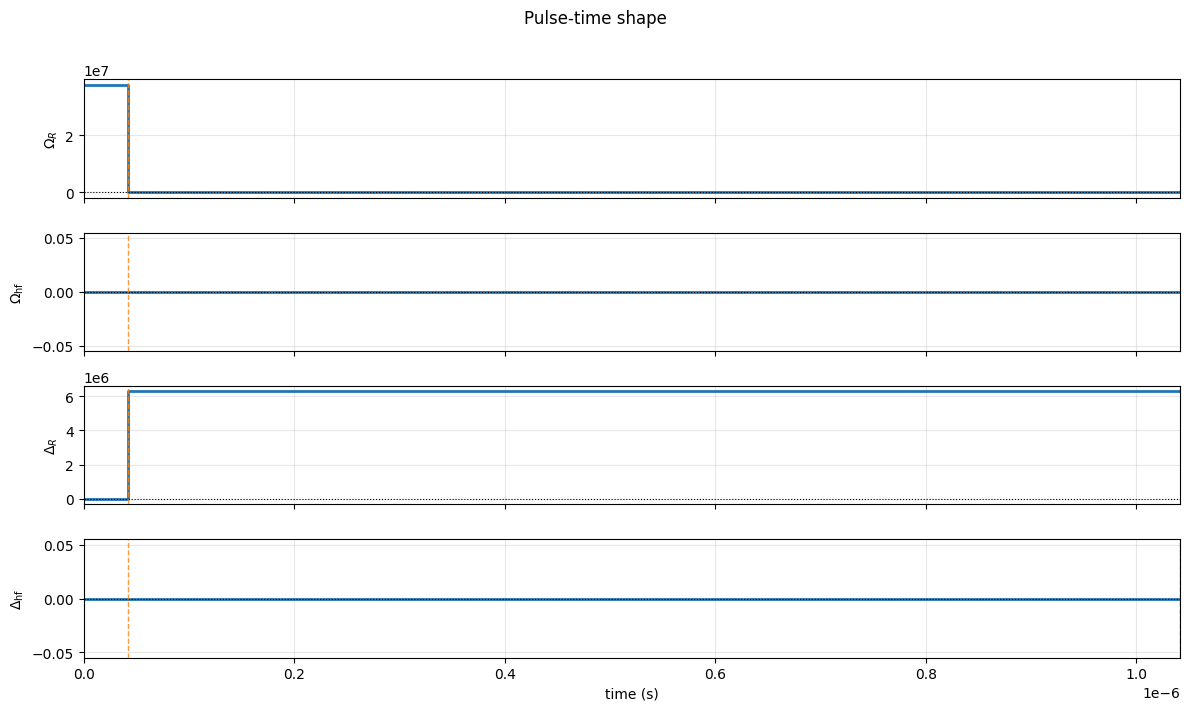

In [2]:
# Plus preparation
OMEGA_R = 2 * np.pi * 6e6
OMEGA_HF = 2 * np.pi * 6e6

t_pi_R = np.pi / OMEGA_R
t_pi2_R = np.pi / (2 * OMEGA_R)

# Ising evolution controls (only delta_R is kept)
DELTA_R_ISING = 2 * np.pi * 1.0e6
T_ISING = 1.0e-6

# Pulse-time shape over full process: prep segment then Ising segment
full_segments = [
    Segment(duration=t_pi2_R, omega_R=OMEGA_R),
    Segment(
        duration=T_ISING,
        omega_R=0.0,
        omega_hf=0.0,
        delta_R=DELTA_R_ISING,
        delta_hf=0.0,
    ),
]

t_prep_end = full_segments[0].duration
t_final = sum(seg.duration for seg in full_segments)

# Pulse-time shape (full_segments schedule)
_proto_fields = (
    ("omega_R", r"$\Omega_R$"),
    ("omega_hf", r"$\Omega_{\rm hf}$"),
    ("delta_R", r"$\Delta_R$"),
    ("delta_hf", r"$\Delta_{\rm hf}$"),
)

_t_edges = [0.0]
for seg in full_segments:
    _t_edges.append(_t_edges[-1] + seg.duration)

fig_p, axes_p = plt.subplots(4, 1, figsize=(12, 7), sharex=True)
for ax_p, (field, label) in zip(axes_p, _proto_fields):
    t_pts, y_pts = [], []
    for j, seg in enumerate(full_segments):
        v = getattr(seg, field)
        t_pts.extend([_t_edges[j], _t_edges[j + 1]])
        y_pts.extend([v, v])
    ax_p.step(t_pts, y_pts, where="post", lw=2, color="tab:blue")
    ax_p.axhline(0.0, color="k", ls=":", lw=0.8)
    ax_p.axvline(t_prep_end, color="tab:orange", ls="--", lw=1, alpha=0.8)
    ax_p.set_ylabel(label)
    ax_p.grid(alpha=0.3)
    ax_p.set_xlim(0.0, t_final)

axes_p[-1].set_xlabel("time (s)")
axes_p[-1].axvline(t_final, color="tab:green", ls="--", lw=1, alpha=0.8)
fig_p.suptitle("Pulse-time shape", y=1.01)
plt.tight_layout()
plt.show()


N=9, prep-end fidelity to (|1> - i|r>)/sqrt(2)^9: 0.9639


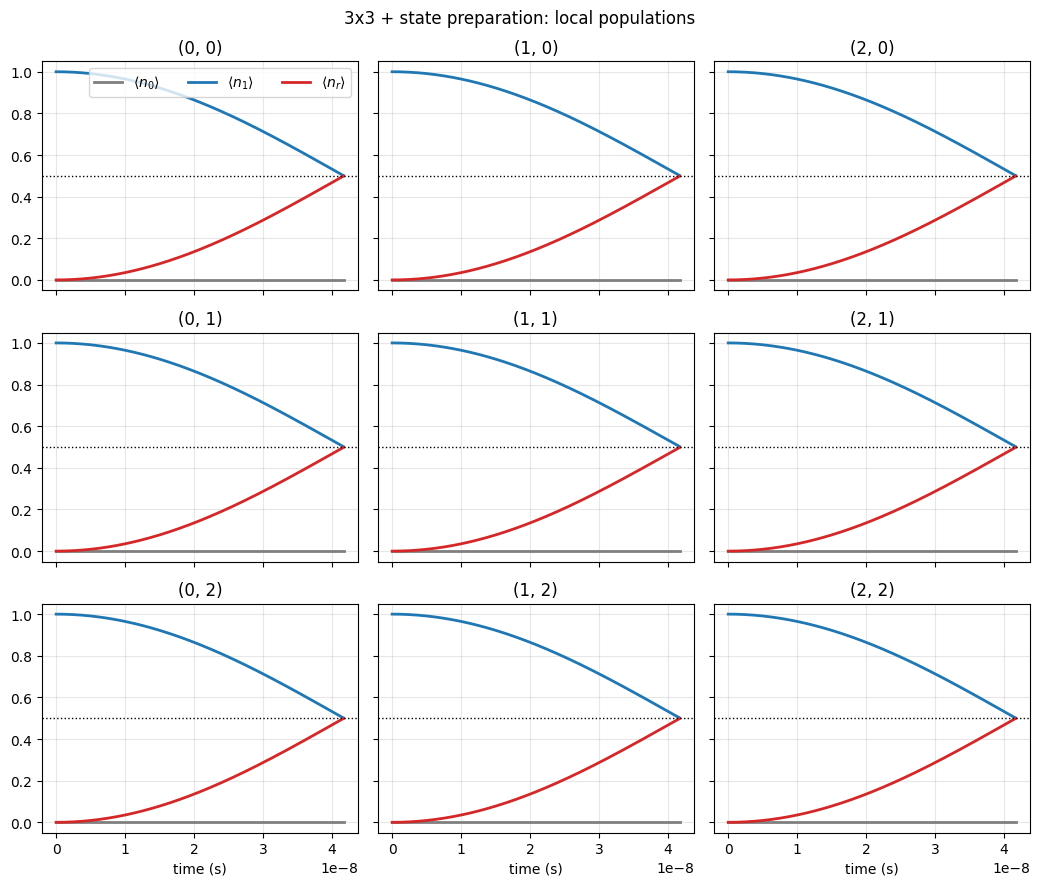

In [3]:
# Stage 1: plus-state preparation
from itertools import product

Lx, Ly = 3, 3
spacing = 10.0
geom = make_square_lattice(Lx, Ly, spacing_um=spacing)
N = geom.N

prep_proto = DigitalAnalogProtocol([full_segments[0]], n_steps=200)

system = RydbergSystem.from_lattice(
    geom,
    level_structure="01r",
    interaction=InteractionSpec(),
    protocol=prep_proto,
)

psi0 = system.product_state(["1"] * N)
res_prep = simulate(system, [], psi0, t_eval=True)
t_prep = np.concatenate([[0.0], res_prep.times])
states_prep = [psi0, *res_prep.states]
psi_plus_init = states_prep[-1]

psi_plus_target = sum(
    (-1j) ** sum(c == "r" for c in cfg) * system.product_state(list(cfg))
    for cfg in product(["1", "r"], repeat=N)
) / (2 ** (N / 2))
fid_prep = np.abs(np.vdot(psi_plus_target, psi_plus_init)) ** 2
print(f"N={N}, prep-end fidelity to (|1> - i|r>)/sqrt(2)^{N}: {fid_prep:.4f}")

levels = tuple(system.basis.local_levels)
pops_site_prep = {
    i: {
        lvl: np.array([system.expectation(f"n_{lvl}_{i}", psi) for psi in states_prep])
        for lvl in levels
    }
    for i in range(N)
}

colors = {"0": "tab:gray", "1": "tab:blue", "r": "tab:red"}
fig, axes = plt.subplots(Ly, Lx, figsize=(3.5 * Lx, 3 * Ly), sharex=True, sharey=True)
for i in range(N):
    ix, iy = i // Ly, i % Ly
    ax = axes[iy, ix]
    for lvl in ("0", "1", "r"):
        ax.plot(t_prep, pops_site_prep[i][lvl], color=colors[lvl], lw=2, label=fr"$\langle n_{lvl}\rangle$")
    ax.axhline(0.5, color="k", ls=":", lw=1)
    ax.set_title(f"({ix}, {iy})")
    ax.grid(alpha=0.3)
    if i == 0:
        ax.legend(loc="upper right", ncol=3)
for ax in axes[-1, :]:
    ax.set_xlabel("time (s)")
fig.suptitle(r"3x3 + state preparation: local populations")
plt.tight_layout()
plt.show()

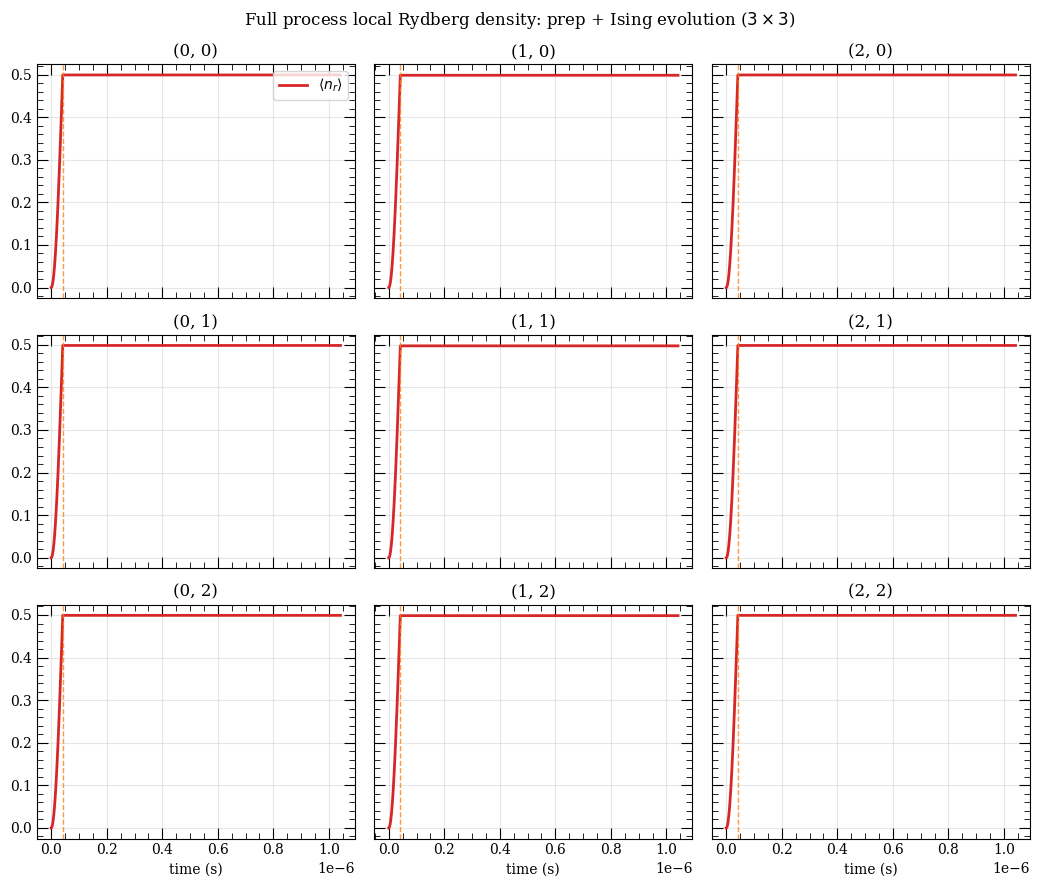

Final local rydberg density <n_r_i>(t_final):
  site 0: 0.499135
  site 1: 0.498437
  site 2: 0.499135
  site 3: 0.498437
  site 4: 0.497491
  site 5: 0.498437
  site 6: 0.499135
  site 7: 0.498437
  site 8: 0.499135


In [24]:
# Stage 2: Ising evolution using prep final state as initial state
# H = sum_{i<j} V_ij n_i^r n_j^r - Delta_R * sum_i n_i^r

ising_proto = DigitalAnalogProtocol([full_segments[1]], n_steps=200)
system.protocol = ising_proto
res_ising = simulate(system, [], psi_plus_init, t_eval=True)

# Stitch full trajectory (prep + ising)
t_offset = t_prep[-1]
t_full = np.concatenate([t_prep, t_offset + res_ising.times])
states_full = [*states_prep, *res_ising.states]

# Local Rydberg density over full process
n_r_site = {
    i: np.array([system.expectation(f"n_r_{i}", psi) for psi in states_full])
    for i in range(N)
}

fig, axes = plt.subplots(Ly, Lx, figsize=(3.5 * Lx, 3 * Ly), sharex=True, sharey=True)
for i in range(N):
    ix, iy = i // Ly, i % Ly
    ax = axes[iy, ix]
    ax.plot(t_full, n_r_site[i], color="tab:red", lw=2, label=r"$\langle n_r\rangle$")
    ax.axvline(t_prep_end, color="tab:orange", ls="--", lw=1, alpha=0.8)
    ax.set_title(f"({ix}, {iy})")
    ax.grid(alpha=0.3)
    if i == 0:
        ax.legend(loc="upper right")
for ax in axes[-1, :]:
    ax.set_xlabel("time (s)")
fig.suptitle(r"Full process local Rydberg density: prep + Ising evolution ($3\times3$)")
plt.tight_layout()
plt.show()

print("Final local rydberg density <n_r_i>(t_final):")
for i in range(N):
    print(f"  site {i}: {n_r_site[i][-1]:.6f}")
